In [1]:
import pandas as pd
import numpy as np

This is for testing the baseline_model and to identify area for feature engineering

In [10]:

df = pd.read_csv("../data/tabular_features.csv")

test = pd.read_csv("../data/splits/test_ids.csv")
train = pd.read_csv("../data/splits/train_ids.csv")
val = pd.read_csv("../data/splits/train_ids.csv")

In [16]:

train_subset = df[df["material_id"].isin(train["material_id"])]
val_subset   = df[df["material_id"].isin(val["material_id"])]
test_subset  = df[df["material_id"].isin(test["material_id"])]

X_train = train_subset.drop(["log_bulk_modulus_vrh", "material_id"], axis=1)
y_train = train_subset["log_bulk_modulus_vrh"]

X_val   = val_subset.drop(["log_bulk_modulus_vrh", "material_id"], axis=1)
y_val   = val_subset["log_bulk_modulus_vrh"]

X_test  = test_subset.drop(["log_bulk_modulus_vrh", "material_id"], axis=1)
y_test  = test_subset["log_bulk_modulus_vrh"]

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import cross_validate
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

models = {
    # it outputs the mean of bulk modulus for comparison
    "1. Dummy Baseline (Mean)": Pipeline([
        ('model', DummyRegressor(strategy='mean'))
    ]),
    
    # Tier 2: Linear Baseline (Needs scaling)
    "2. Scaled Linear (Ridge)": Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),
    
    "3. Random Forest": Pipeline([
        ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    ]),
    
    "4. Gradient Boosting (Hist)": Pipeline([
        ('model', HistGradientBoostingRegressor(learning_rate=0.1, random_state=42))
    ])
}

results = []
metrics = ['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2']

for name, pipeline in models.items():
    cv_scores = cross_validate(pipeline, X_train, y_train, cv=5, scoring=metrics, n_jobs=-1)
    
    rmse = -cv_scores['test_neg_root_mean_squared_error'].mean()
    mae = -cv_scores['test_neg_mean_absolute_error'].mean()
    r2 = cv_scores['test_r2'].mean()
    
    results.append({
        'Model': name,
        'CV RMSE': round(rmse, 3),
        'CV MAE': round(mae, 3),
        'CV R²': round(r2, 4)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))


                      Model  CV RMSE  CV MAE   CV R²
   1. Dummy Baseline (Mean)    0.350   0.275 -0.0482
   2. Scaled Linear (Ridge)    0.120   0.080  0.8733
           3. Random Forest    0.104   0.063  0.9033
4. Gradient Boosting (Hist)    0.095   0.056  0.9196


In [14]:
best_pipeline = models["4. Gradient Boosting (Hist)"]
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)

print("=== FINAL TEST SET PERFORMANCE ===")
print(f"Test RMSE: {root_mean_squared_error(y_test, y_pred):.3f} GPa")
print(f"Test MAE:  {mean_absolute_error(y_test, y_pred):.3f} GPa")
print(f"Test R²:   {r2_score(y_test, y_pred):.4f}")

=== FINAL TEST SET PERFORMANCE ===
Test RMSE: 15.649 GPa
Test MAE:  9.970 GPa
Test R²:   0.9497


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

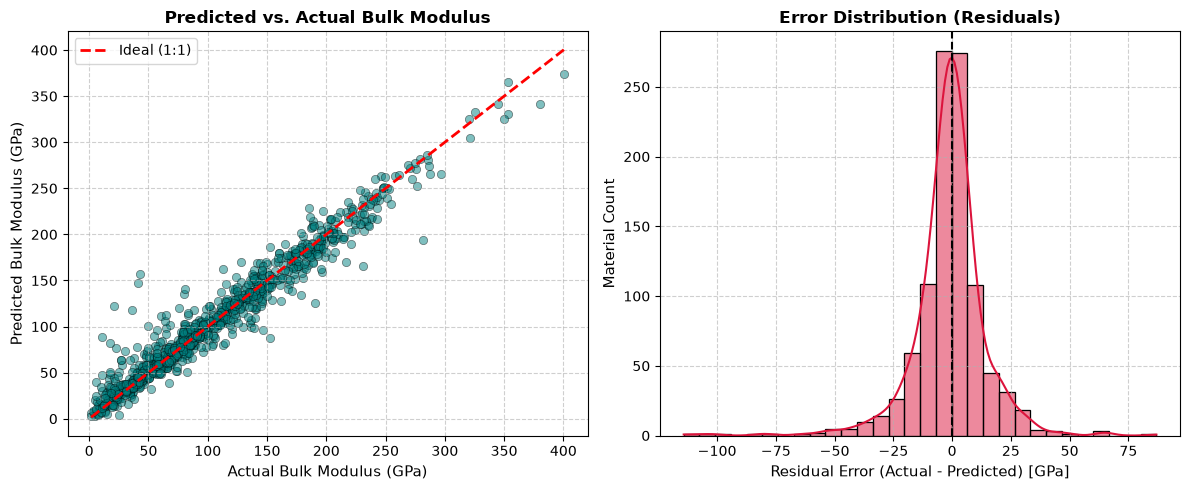


--- TOP 10 LARGEST PREDICTION FAILURES (HIGH RESIDUALS) ---
      Actual_Bulk_Modulus  Predicted_Bulk_Modulus  Absolute_Error_GPa  Residual_GPa
3501               42.606              156.804901          114.198901   -114.198901
1988               40.769              147.087438          106.318438   -106.318438
4525               21.309              122.033656          100.724656   -100.724656
1860              281.200              194.296278           86.903722     86.903722
2417               35.899              117.881289           81.982289    -81.982289
1075               11.036               88.766443           77.730443    -77.730443
1907              231.003              165.753755           65.249245     65.249245
3316               17.135               82.359444           65.224444    -65.224444
2602              152.126               87.456755           64.669245     64.669245
1018              190.453              125.846962           64.606038     64.606038


In [18]:

residuals = np.abs(y_test - y_pred)
error_df = pd.DataFrame({
    'Actual_Bulk_Modulus': y_test,
    'Predicted_Bulk_Modulus': y_pred,
    'Absolute_Error_GPa': residuals,
    'Residual_GPa': y_test - y_pred 
})

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5, color='teal', edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal (1:1)')
plt.xlabel('Actual Bulk Modulus (GPa)', fontsize=11)
plt.ylabel('Predicted Bulk Modulus (GPa)', fontsize=11)
plt.title('Predicted vs. Actual Bulk Modulus', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
sns.histplot(error_df['Residual_GPa'], kde=True, color='crimson', bins=30)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
plt.xlabel('Residual Error (Actual - Predicted) [GPa]', fontsize=11)
plt.ylabel('Material Count', fontsize=11)
plt.title('Error Distribution (Residuals)', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print("\n--- TOP 10 LARGEST PREDICTION FAILURES (HIGH RESIDUALS) ---")
worst_errors = error_df.sort_values(by='Absolute_Error_GPa', ascending=False).head(10)
print(worst_errors.to_string())

=== 2. CALCULATING PERMUTATION FEATURE IMPORTANCE ===

Top 15 Most Important Physical Features Driving the Model:
                             Feature  Importance_Mean  Importance_Std
            MagpieData mean MeltingT         0.358344        0.009350
         MagpieData mean GSvolume_pa         0.176127        0.005918
         MagpieData avg_dev MeltingT         0.019812        0.001181
      MagpieData maximum GSvolume_pa         0.019529        0.001902
   MagpieData mean Electronegativity         0.019278        0.001830
  MagpieData maximum MendeleevNumber         0.014707        0.001450
MagpieData minimum Electronegativity         0.012225        0.000891
        MagpieData minimum NUnfilled         0.011048        0.001057
          MagpieData mean NdUnfilled         0.010850        0.001161
         MagpieData mode GSvolume_pa         0.008821        0.000957
  MagpieData minimum MendeleevNumber         0.006559        0.001048
     MagpieData mode MendeleevNumber         0

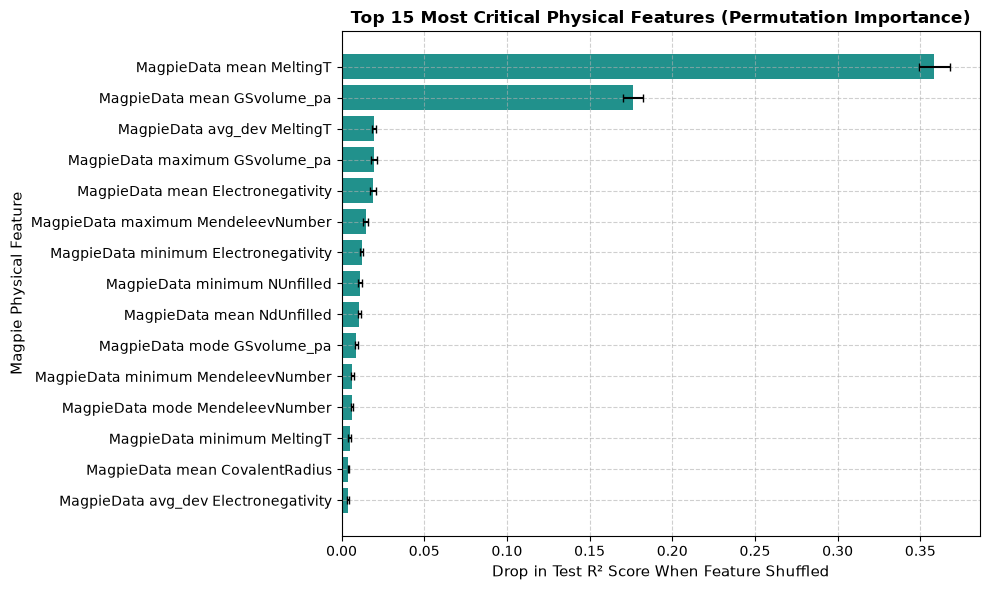

In [23]:
print("=== 2. CALCULATING PERMUTATION FEATURE IMPORTANCE ===")

perm_importance = permutation_importance(best_pipeline, X_test, y_test, n_repeats=10, random_state=42, scoring ='r2')

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance_Mean': perm_importance.importances_mean,
    'Importance_Std': perm_importance.importances_std
}).sort_values(by='Importance_Mean', ascending=False)

print("\nTop 15 Most Important Physical Features Driving the Model:")
print(importance_df.head(15).to_string(index=False))

plt.figure(figsize=(10, 6))
top_15 = importance_df.head(15).iloc[::-1] 

plt.barh(
    top_15['Feature'], 
    top_15['Importance_Mean'], 
    xerr=top_15['Importance_Std'], 
    color='#21918c', 
    ecolor='black', 
    capsize=3
)

plt.xlabel('Drop in Test R² Score When Feature Shuffled', fontsize=11)
plt.ylabel('Magpie Physical Feature', fontsize=11)
plt.title('Top 15 Most Critical Physical Features (Permutation Importance)', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()